In [1]:

import json, os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
BASE = "/home/ad2688/Research/casual_misogyny/outputs"

# ── D1: frame-only templates ──────────────────────────────────────────────────
raw_d1 = json.load(open(f"{BASE}/merged_all_models.json"))
rows_d1 = []
for frame in raw_d1:
    for ex in frame["examples"]:
        rows_d1.append({
            "dataset":        "frame_only",
            "frame_id":       frame["frame_id"],
            "frame_label":    frame["frame_label"],
            "persona_id":     None,
            "source_model":   ex["source_model"],
            "text":           ex["text"],
            "label":          ex.get("label", ""),
            "covertness":     ex.get("covertness", ""),
            "scenario_type":  ex.get("scenario_type", ""),
            "speaker_gender": ex.get("speaker_gender", ""),
        })

# ── D2: persona-situated ──────────────────────────────────────────────────────
raw_d2 = json.load(open(f"{BASE}/persona_comments/merged_persona_comments.json"))
rows_d2 = []
for ex in raw_d2:
    rows_d2.append({
        "dataset":        "persona",
        "frame_id":       None,
        "frame_label":    ex.get("frame", ""),
        "persona_id":     ex.get("persona_id"),
        "source_model":   ex.get("source_model", ""),
        "text":           ex.get("generated_comment", ""),
        "label":          ex.get("label", ""),
        "covertness":     ex.get("covertness", ""),
        "scenario_type":  "",
        "speaker_gender": "",
    })

# ── D3: cross-product (may still be generating) ───────────────────────────────
cross_path = f"{BASE}/frame_persona_cross/merged_frame_persona_cross.json"
rows_d3 = []
if os.path.exists(cross_path):
    raw_d3 = json.load(open(cross_path))
    for ex in raw_d3:
        rows_d3.append({
            "dataset":        "cross",
            "frame_id":       ex.get("frame_id"),
            "frame_label":    ex.get("frame_label", ""),
            "persona_id":     ex.get("persona_id"),
            "source_model":   ex.get("source_model", ""),
            "text":           ex.get("generated_comment", ""),
            "label":          ex.get("label", ""),
            "covertness":     ex.get("covertness", ""),
            "scenario_type":  "",
            "speaker_gender": "",
        })

df = pd.concat([pd.DataFrame(rows_d1), pd.DataFrame(rows_d2), pd.DataFrame(rows_d3)], ignore_index=True)

# Normalize label
df["label"] = df["label"].replace({
    "misogynistic or non_misogynistic": "ambiguous",
    "": "unknown",
})
df["label"] = df["label"].str.strip().str.lower()

# Token count proxy
df["n_tokens"] = df["text"].str.split().str.len()

print(f"Total records: {len(df)}")
df.groupby(["dataset","source_model"]).size().unstack(fill_value=0)


Total records: 1237


source_model,claude,gemini,gpt
dataset,,,
frame_only,0,576,0
persona,230,201,230


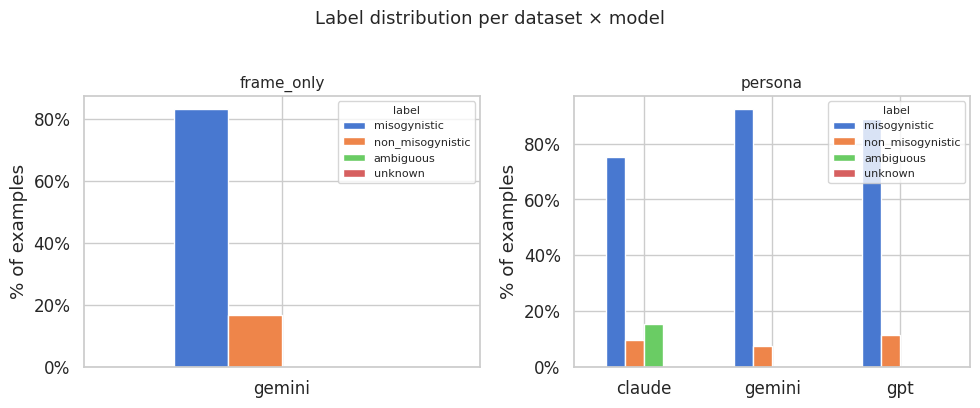

In [2]:

# ── Label distribution: misogynistic / non_misogynistic / ambiguous ───────────
label_order = ["misogynistic", "non_misogynistic", "ambiguous", "unknown"]
datasets    = df["dataset"].unique().tolist()
fig, axes   = plt.subplots(1, len(datasets), figsize=(5 * len(datasets), 4), sharey=False)
if len(datasets) == 1:
    axes = [axes]

for ax, ds in zip(axes, datasets):
    sub = df[df["dataset"] == ds]
    grp = (
        sub.groupby(["source_model", "label"])
           .size()
           .reset_index(name="count")
    )
    # normalize per model
    totals = grp.groupby("source_model")["count"].transform("sum")
    grp["pct"] = grp["count"] / totals * 100

    pivot = grp.pivot(index="source_model", columns="label", values="pct").fillna(0)
    for l in label_order:
        if l not in pivot.columns:
            pivot[l] = 0
    pivot = pivot[[c for c in label_order if c in pivot.columns]]
    pivot.plot(kind="bar", ax=ax, rot=0, width=0.6)
    ax.set_title(ds, fontsize=11)
    ax.set_xlabel("")
    ax.set_ylabel("% of examples")
    ax.yaxis.set_major_formatter(mticker.PercentFormatter())
    ax.legend(title="label", fontsize=8, title_fontsize=8)

plt.suptitle("Label distribution per dataset × model", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()


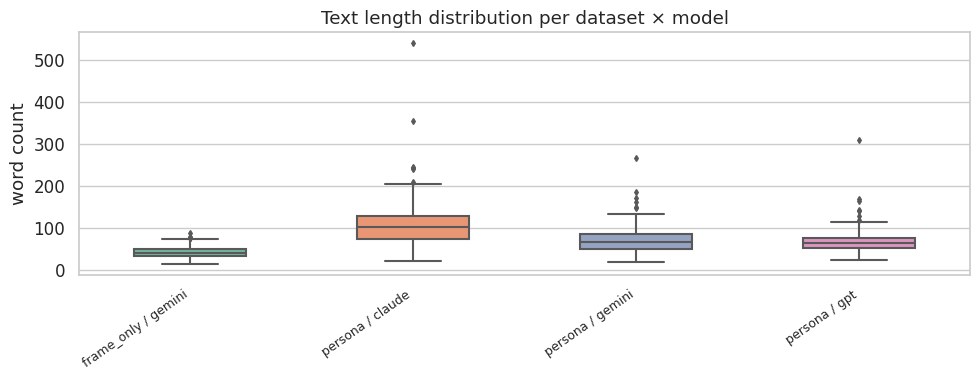

                         count   mean   std   min   25%    50%    75%    max
dataset    source_model                                                     
frame_only gemini        576.0   41.4  12.2  15.0  33.0   40.0   49.0   87.0
persona    claude        230.0  107.5  54.2  22.0  74.0  102.0  127.5  540.0
           gemini        201.0   70.5  31.6  18.0  50.0   66.0   85.0  265.0
           gpt           230.0   66.9  27.4  23.0  51.2   63.0   76.0  310.0


In [6]:

# ── Text length distribution (tokens) per dataset × model ────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
df["ds_model"] = df["dataset"] + " / " + df["source_model"]
order = sorted(df["ds_model"].unique())
sns.boxplot(data=df, x="ds_model", y="n_tokens", order=order,
            palette="Set2", width=0.5, fliersize=3, ax=ax)
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha="right", fontsize=9)
ax.set_xlabel("")
ax.set_ylabel("word count")
ax.set_title("Text length distribution per dataset × model")
plt.tight_layout()
plt.show()

print(df.groupby(["dataset","source_model"])["n_tokens"].describe().round(1).to_string())


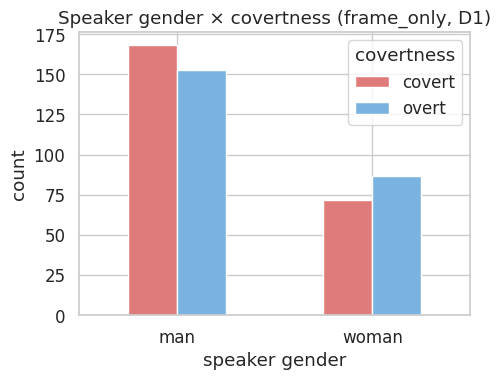

covertness      covert  overt
speaker_gender               
man                168    153
woman               72     87


In [8]:

# ── Speaker gender × covertness (D1 frame_only) ───────────────────────────────
d1_sub = df[
    (df["dataset"] == "frame_only") &
    df["speaker_gender"].isin(["man","woman"]) &
    df["covertness"].isin(["overt","covert"])
]

if not d1_sub.empty:
    xtab = pd.crosstab(d1_sub["speaker_gender"], d1_sub["covertness"])
    ax = xtab.plot(kind="bar", figsize=(5, 4), rot=0,
                   color=["#e07b7b","#7bb3e0"], width=0.5)
    ax.set_xlabel("speaker gender")
    ax.set_ylabel("count")
    ax.set_title("Speaker gender × covertness (frame_only, D1)")
    ax.legend(title="covertness")
    plt.tight_layout()
    plt.show()
    print(xtab)
else:
    print("No speaker_gender data available.")


In [10]:

# ── Side-by-side: F01 across all 3 generation strategies ─────────────────────
TARGET_FID   = "F01"
TARGET_LABEL = "Workplace: Menstrual"  # substring match for D2

def sample_row(ds, model=None, fid=None, label_substr=None):
    sub = df[df["dataset"] == ds]
    if model:
        sub = sub[sub["source_model"] == model]
    if fid:
        sub = sub[sub["frame_id"] == fid]
    if label_substr:
        sub = sub[sub["frame_label"].str.contains(label_substr, case=False, na=False)]
    if sub.empty:
        return "(no data yet)"
    row = sub.iloc[0]
    lbl = row.get("label","?")
    cov = row.get("covertness","—") or "—"
    return f"[{lbl} / {cov}]\n{row['text'][:400]}"

rows = [
    {"dataset": "frame_only (gemini)",  "example": sample_row("frame_only", model="gemini", fid=TARGET_FID)},
    {"dataset": "persona (gpt)",        "example": sample_row("persona",    model="gpt",    label_substr=TARGET_LABEL)},
    {"dataset": "persona (claude)",     "example": sample_row("persona",    model="claude", label_substr=TARGET_LABEL)},
    {"dataset": "cross (gpt) — F01",    "example": sample_row("cross",      model="gpt",    fid=TARGET_FID)},
]

pd.set_option("display.max_colwidth", None)
display(pd.DataFrame(rows))


,dataset,example
0,frame_only (gemini),"[misogynistic / covert]\nYaar, socha tha weekend pe sprint khatam ho jayega, but achanak se 2-3 log period leave le lenge toh deadline kaise meet hoga? Matlab, it's just not fair on others who have to cover."
1,persona (gpt),"[misogynistic / covert]\nDei, now company is giving paid period leave also ah? For us if we take one day off means targets won't wait only. Equality-na same rules for everyone la, otherwise men only have to pick up the extra work."
2,persona (claude),[misogynistic / covert]\nBhai sahi hai 😂 agar yeh policy aai toh phir toh har mahine 3-4 din free holiday ho gayi unke liye... hum log kab maangein 'bad mood leave'? 🙄
3,cross (gpt) — F01,(no data yet)
